# Female Deepfake Speech Audio Detection Model

## The explanations for this notebook are in the full report. This notebook is more focused on generating the figures and results.

This notebook walks through the analysis of deepfake audio detection models that are trained only using female audio samples.

## Motivation
I wanted to investigate the effectiveness of machine/deep learning models on sparse data.

## Research Subquestion(s)
- Do machine/deep learning models that are trained only on male audio generalize to female audio? If so, why?
- What are some of the most important features in differentiating real and fake male audio samples?

## Models Used
- Simple Neural Network
- Complex Neural Network
- Extreme Gradient Boosting

In [1]:
from google.colab import drive
drive.mount('/content/drive')
import librosa
import librosa.feature
import numpy as np
import librosa.display
import matplotlib.pyplot as plt
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import confusion_matrix
import pandas as pd
import numpy as np
import os
import seaborn as sns
import shap
from sklearn.metrics import classification_report
import xgboost as xgb

# define torch device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

Mounted at /content/drive


## Data Pre-processing

- Relevant audio features and labels have been extracted from the data via audio_processing.py. For the sake of simplicity, the dataset generated from that script will be loaded here.

In [2]:
# Load the female audio data
combined_female_df = pd.read_csv("/content/drive/My Drive/LING_199/combined_female_df.csv")

# rename 'label' to 'LABEL' if necessary
if 'label' in combined_female_df.columns and 'LABEL' not in combined_female_df.columns:
    combined_female_df = combined_female_df.rename(columns={'label': 'LABEL'})

# rename 'FAKE' as 1 and 'REAL' as 0 if necessary
if 'FAKE' in combined_female_df['LABEL'].unique() and 'REAL' in combined_female_df['LABEL'].unique():
    combined_female_df['LABEL'] = combined_female_df['LABEL'].map({'FAKE': 1, 'REAL': 0})

# randomly undersample the fake class to be the same as the real class
fake_samples = combined_female_df[combined_female_df['LABEL'] == 1]
real_samples = combined_female_df[combined_female_df['LABEL'] == 0]
fake_samples_undersampled = fake_samples.sample(n=len(real_samples), random_state=42)
combined_female_df = pd.concat([real_samples, fake_samples_undersampled])

# Separate features and labels
X_female = combined_female_df.drop(columns=['LABEL']).values
y_female = combined_female_df['LABEL'].values

# Split into training and testing sets
X_train_female, X_test_female, y_train_female, y_test_female = train_test_split(
    X_female, y_female, test_size=0.2, stratify=y_female, random_state=42
)

# load the full male data
combined_male_df = pd.read_csv("/content/drive/My Drive/LING_199/combined_male_df.csv")

# balance the data based on label
fake_samples = combined_male_df[combined_male_df['label'] == 1]
real_samples = combined_male_df[combined_male_df['label'] == 0]
fake_samples_undersampled = fake_samples.sample(n=len(real_samples), random_state=42)
combined_male_df = pd.concat([real_samples, fake_samples_undersampled])

## Simple Neural Network

First, I fit a simple neural network to the female data and gauged its effectiveness on a female test set, as well as a male test set.

In [3]:
# Simple Neural Network Class
class SimpleNN(nn.Module):
    def __init__(self, input_size, num_classes):
        super(SimpleNN, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, 128),
            nn.ReLU(inplace=False),
            nn.Linear(128, 64),
            nn.ReLU(inplace=False),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        return self.net(x)

In [4]:
# Load a previously trained female model
female_model = torch.load('/content/drive/My Drive/LING_199/trained_models/female_models/95.59_basic_female_model_balanced.pth', weights_only=False)

In [5]:
'''
Classification report on Basic NN female model on its own test set
'''

# Collect all test data in a single tensor
X_test_tensor_female = torch.tensor(X_test_female, dtype=torch.float32).to(device)
with torch.no_grad():
    logits = female_model(X_test_tensor_female)
    probabilities = torch.softmax(logits, dim=1).cpu().numpy()

predicted_labels = np.argmax(probabilities, axis=1)
print("\nClassification Report:")
print(classification_report(y_test_female, predicted_labels, target_names=["REAL", "FAKE"], zero_division=1))


Classification Report:
              precision    recall  f1-score   support

        REAL       0.94      0.98      0.96       136
        FAKE       0.98      0.93      0.95       136

    accuracy                           0.96       272
   macro avg       0.96      0.96      0.96       272
weighted avg       0.96      0.96      0.96       272



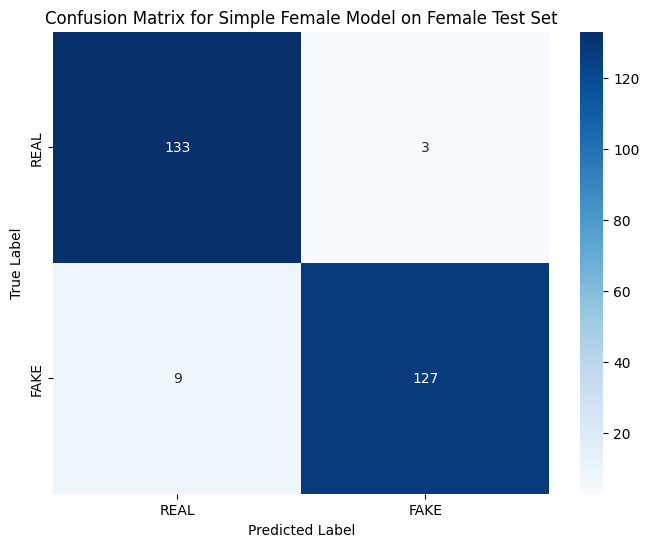

In [6]:
# confusion matrix for female test set
cm = confusion_matrix(y_test_female, predicted_labels)
cm_df = pd.DataFrame(cm, index=["REAL", "FAKE"], columns=["REAL", "FAKE"])

plt.figure(figsize=(8, 6))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix for Simple Female Model on Female Test Set")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

Trained Basic Female Model on Male Dataset Accuracy: 0.5158


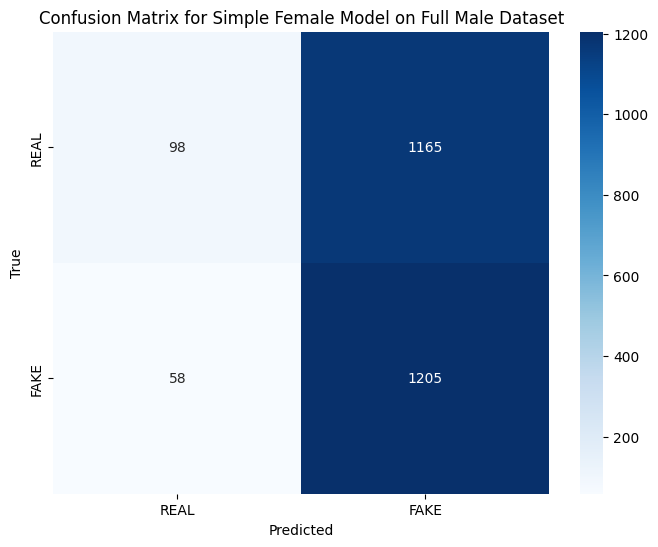

In [7]:
# Confusion matrix for female simple model on male dataset

# Ensure correct column order and drop label if present
feature_names = combined_male_df.columns.drop('label').tolist()
X_new = combined_male_df[feature_names].values  # use same feature_names list from training

# Convert to tensor and send to device
X_new_tensor = torch.tensor(X_new, dtype=torch.float32).to(device)

# set the model to evaluation mode
female_model.eval()
with torch.no_grad():
    outputs = female_model(X_new_tensor)
    _, predictions = torch.max(outputs, 1)  # For classification

# Use the labels from the male dataframe
y_new = combined_male_df['label'].values
y_new_tensor = torch.tensor(y_new, dtype=torch.long).to(device)

correct = (predictions == y_new_tensor).sum().item()
accuracy = correct / len(y_new)
print(f"Trained Basic Female Model on Male Dataset Accuracy: {accuracy:.4f}")

# instead of doing just accuracy, make a confusion matrix
cm = confusion_matrix(y_new, predictions.cpu().numpy())

## format the confusion matrix and plot
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['REAL', 'FAKE'], yticklabels=['REAL', 'FAKE'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix for Simple Female Model on Full Male Dataset')
plt.show()

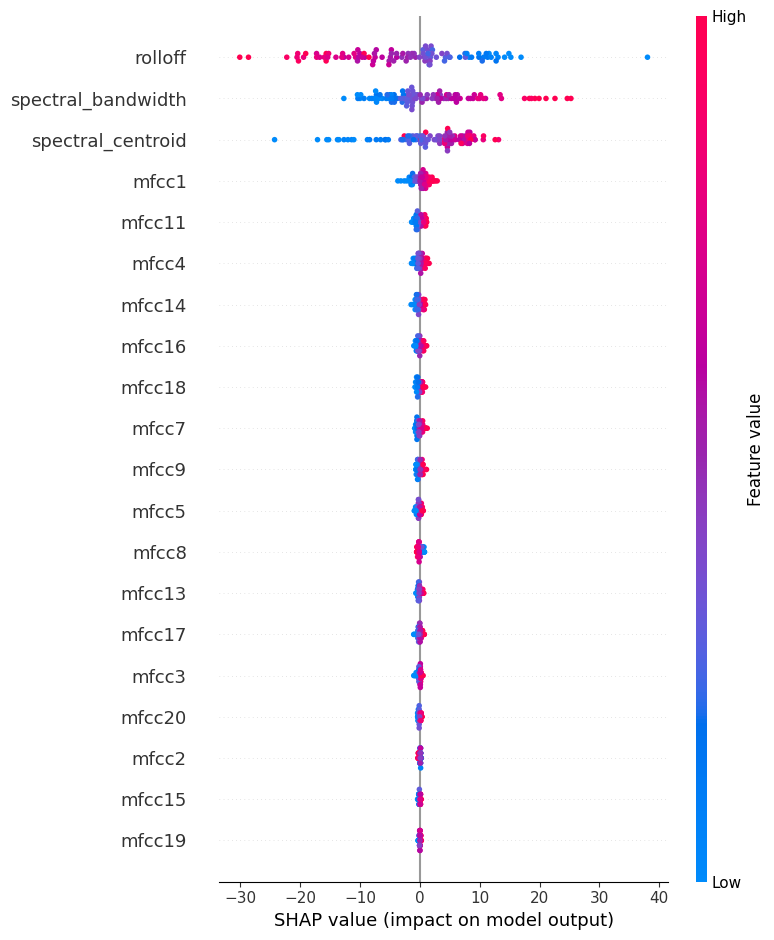

In [8]:
'''Simple Female Model SHAP Feature Importance
'''

# prepare background
background = torch.tensor(X_train_female[:100], dtype=torch.float32).to(device)

# get 100 test samples
X_test_tensor = torch.tensor(X_test_female[:100], dtype=torch.float32).to(device)

# Create a SHAP GradientExplainer
explainer = shap.GradientExplainer(female_model, background)

# Get SHAP values for a subset of the test set
shap_values = explainer.shap_values(X_test_tensor_female[:100])

# reshape
shap_values = shap_values[:, :, 1]

# extract feature names from original dataframe
feature_names = combined_female_df.drop(columns=['LABEL']).columns.tolist()

# reshape again if needed
if isinstance(shap_values, list):
    shap_values = shap_values[0]

# Convert to numpy if needed
if torch.is_tensor(shap_values):
    shap_values = shap_values.cpu().numpy()

# Create SHAP summary plot
shap.summary_plot(shap_values, X_test_female[:100], feature_names=feature_names, rng=42)

# Complex Neural Network

In [9]:
# Complex Neural Network Class
class Swish(nn.Module):
    def forward(self, x):
        return x * torch.sigmoid(x)

class ImprovedComplexNN(nn.Module):
    def __init__(self, input_size):
        super(ImprovedComplexNN, self).__init__()

        self.fc1 = nn.Linear(input_size, 256)
        self.bn1 = nn.BatchNorm1d(256)
        self.act1 = nn.ReLU()
        self.dropout1 = nn.Dropout(0.3)

        self.fc2 = nn.Linear(256, 128)
        self.bn2 = nn.BatchNorm1d(128)
        self.act2 = nn.ReLU()
        self.dropout2 = nn.Dropout(0.3)

        self.fc3 = nn.Linear(128, 64)
        self.bn3 = nn.BatchNorm1d(64)
        self.act3 = nn.ReLU()
        self.dropout3 = nn.Dropout(0.3)

        self.fc4 = nn.Linear(64, 32)
        self.bn4 = nn.BatchNorm1d(32)
        self.act4 = Swish()

        self.fc5 = nn.Linear(32, 1)

    def forward(self, x):
        x = self.fc1(x)
        x = self.bn1(x)
        x = self.act1(x)
        x = self.dropout1(x)

        x = self.fc2(x)
        x = self.bn2(x)
        x = self.act2(x)
        x = self.dropout2(x)

        x = self.fc3(x)
        x = self.bn3(x)
        x = self.act3(x)
        x = self.dropout3(x)

        x = self.fc4(x)
        x = self.bn4(x)
        x = self.act4(x)

        x = self.fc5(x)
        return torch.sigmoid(x)

In [10]:
# load a previously trained complex female model
complex_female_model = torch.load('/content/drive/My Drive/LING_199/trained_models/female_models/97.93_complex_female_model.pth', weights_only=False, map_location=torch.device(device))

In [11]:
'''Classification report on Complex Female model's own test dataset
'''

# Collect all test data in a single tensor
X_test_tensor = torch.tensor(X_test_female, dtype=torch.float32).to(device)

# Get predicted probabilities
with torch.no_grad():
    probs = complex_female_model(X_test_tensor).cpu().numpy().flatten()  # Shape: (N,)
    predicted_labels = (probs > 0.5).astype(int)

# Classification report
print("\nClassification Report:")
print(classification_report(y_test_female, predicted_labels, target_names=["REAL", "FAKE"]))


Classification Report:
              precision    recall  f1-score   support

        REAL       1.00      0.93      0.97       136
        FAKE       0.94      1.00      0.97       136

    accuracy                           0.97       272
   macro avg       0.97      0.97      0.97       272
weighted avg       0.97      0.97      0.97       272



Accuracy: 0.9669


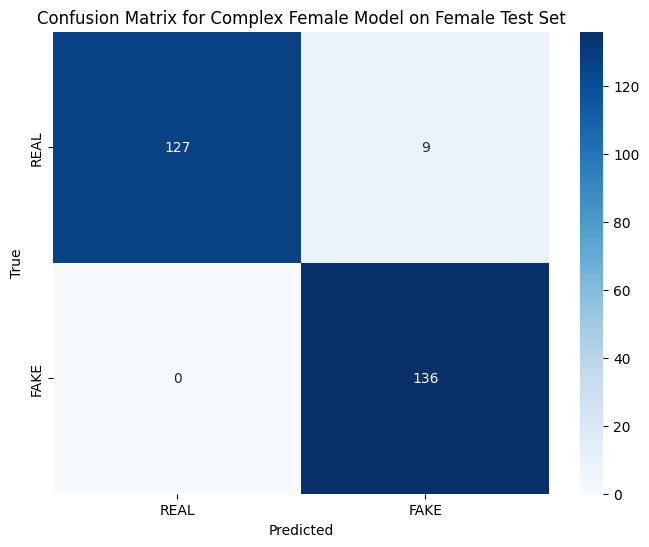

In [12]:
'''Confusion Matrix for Complex Female Model on Female Test Set
'''
cm = confusion_matrix(y_test_female, predicted_labels)
cm_df = pd

# print accuracy
accuracy = (cm[0][0] + cm[1][1]) / (cm[0][0] + cm[0][1] + cm[1][0] + cm[1][1])
print(f"Accuracy: {accuracy:.4f}")

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['REAL', 'FAKE'], yticklabels=['REAL', 'FAKE'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix for Complex Female Model on Female Test Set')
plt.show()


Accuracy: 0.7395


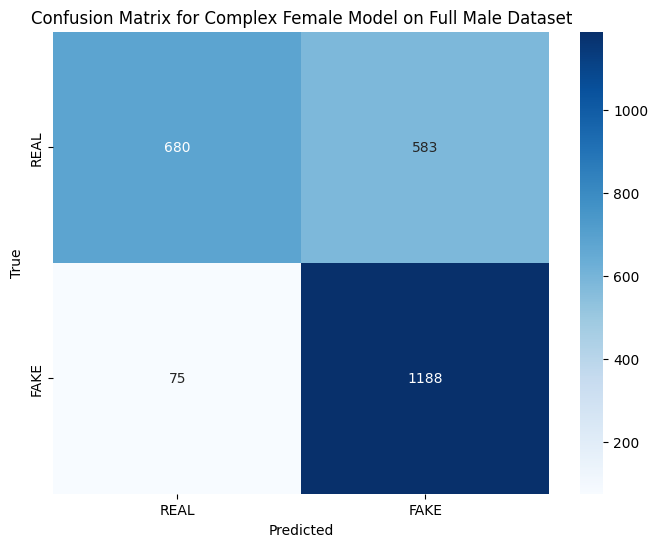

In [13]:
'''Confusion Matrix for Complex Female Model on Full Male Dataset
'''

"""
Testing the complex female model on the male dataset
"""

# Collect all male data into a tensor
X_test_tensor = torch.tensor(X_new, dtype=torch.float32).to(device)

# Get predicted probabilities
with torch.no_grad():
    probs = complex_female_model(X_test_tensor).cpu().numpy().flatten()  # Shape: (N,)
    predicted_labels = (probs > 0.5).astype(int)

# Confusion matrix
cm = confusion_matrix(y_new, predicted_labels)

# print accuracy
accuracy = (cm[0][0] + cm[1][1]) / (cm[0][0] + cm[0][1] + cm[1][0] + cm[1][1])
print(f"Accuracy: {accuracy:.4f}")

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['REAL', 'FAKE'], yticklabels=['REAL', 'FAKE'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix for Complex Female Model on Full Male Dataset')
plt.show()

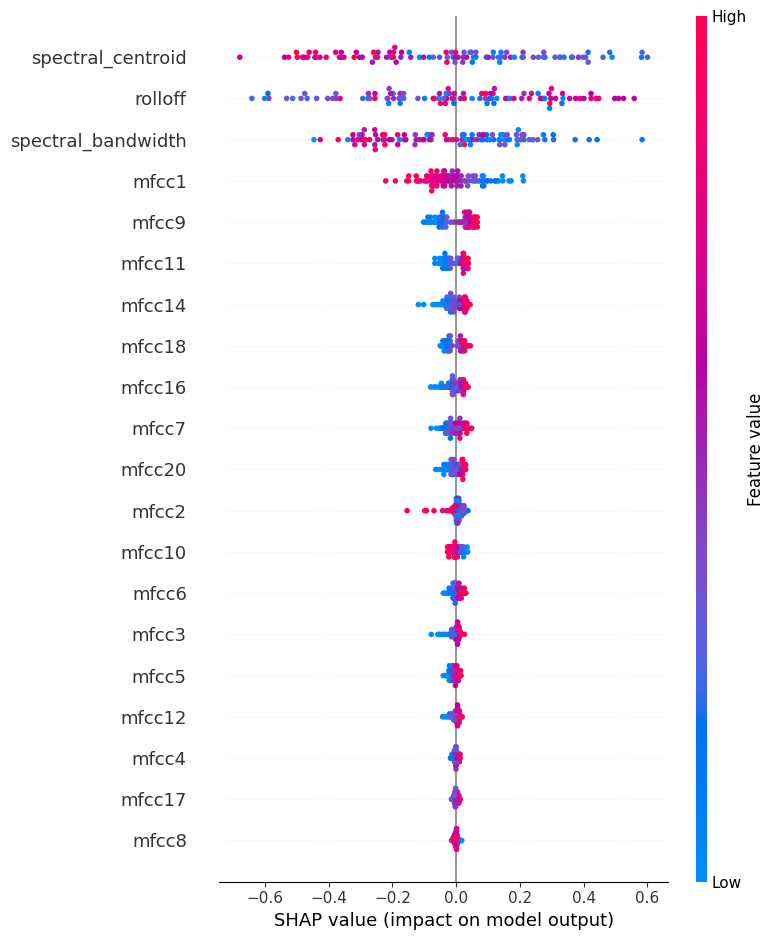

In [14]:
'''Shap plot for Complex Female Model
'''

# Convert model to evaluation mode
complex_female_model.eval()

# get background
background = torch.tensor(X_train_female[:100], dtype=torch.float32).to(device)

# subset the first 100 test samples for feature explanation
X_test_tensor = torch.tensor(X_test_female[:100], dtype=torch.float32).to(device)

# Create a SHAP GradientExplainer
explainer = shap.GradientExplainer(complex_female_model, background)

# Get SHAP values for a subset of the test set
shap_values = explainer.shap_values(X_test_tensor_female[:100])

# reshape
shap_values = shap_values.squeeze(-1)

# extract feature names from original dataframe
feature_names = combined_female_df.drop(columns=['LABEL']).columns.tolist()

if isinstance(shap_values, list):
    shap_values = shap_values[0]  # Shape: (samples, features)

# Convert to numpy if needed
if torch.is_tensor(shap_values):
    shap_values = shap_values.cpu().numpy()

# Create SHAP summary plot
shap.summary_plot(shap_values, X_test_female[:100], feature_names=feature_names, rng=42)

# Extreme Gradient Boosting

In [15]:
# load female dataset
df = pd.read_csv("/content/drive/My Drive/LING_199/combined_female_df.csv")

# rename 'label' to 'LABEL' if needed
if 'label' in df.columns and 'LABEL' not in df.columns:
    df.rename(columns={'label': 'LABEL'}, inplace=True)

# convert all 'REAL' to 0 and 'FAKE' to 1 in the 'LABEL' column if REAL and FAKE are in the 'LABEL' column
if 'REAL' in df['LABEL'].values and 'FAKE' in df['LABEL'].values:
    df['LABEL'] = df['LABEL'].replace({'REAL': 0, 'FAKE': 1})

# 1. Prepare the data
X = df.drop('LABEL', axis=1)  # Features (all columns except 'LABEL')
y = df['LABEL']               # Target variable

# 2. Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,    # 20% for testing
    random_state=42,
    stratify=y        # Maintain class distribution
)

# Create DMatrix for XGBoost (optimized data structure)
dtrain = xgb.DMatrix(X_train, label=y_train)
dtest = xgb.DMatrix(X_test, label=y_test)

In [16]:
# load a xgb female model
model = xgb.Booster()
model.load_model('/content/drive/My Drive/LING_199/trained_models/female_models/99.38_xgb_female_model.json')

In [17]:
'''Classification report on XGB female model's own test data
'''
from sklearn.metrics import accuracy_score, classification_report

# Make predictions
y_pred_proba = model.predict(dtest)  # Probabilities
y_pred = (y_pred_proba > 0.5).astype(int)  # Class predictions

# Evaluate the model
print("\nModel Evaluation:")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Model Evaluation:
Accuracy: 0.9938

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       136
           1       0.99      1.00      1.00       348

    accuracy                           0.99       484
   macro avg       0.99      0.99      0.99       484
weighted avg       0.99      0.99      0.99       484



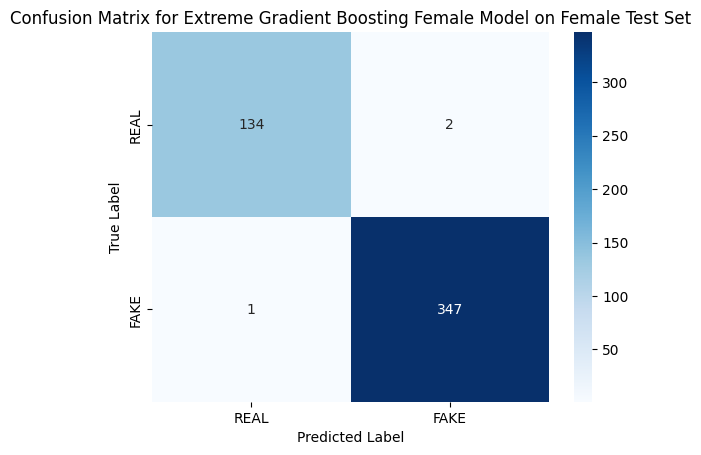

In [18]:
# Confusion matrix of xgboost female model on female test set
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['REAL', 'FAKE'], yticklabels=['REAL', 'FAKE'])
plt.title('Confusion Matrix for Extreme Gradient Boosting Female Model on Female Test Set')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

Accuracy: 0.60


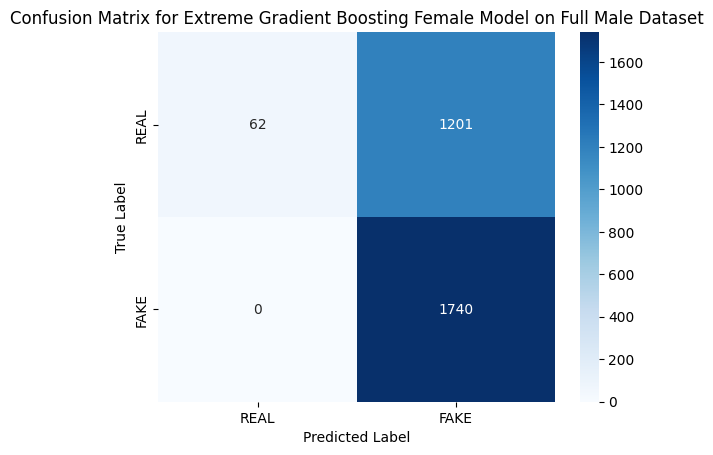

In [19]:
'''Test the female XGB model on the male dataset
'''

# load the female dataset
male_combined_df = pd.read_csv("/content/drive/My Drive/LING_199/combined_male_df.csv")

# rename 'label' to 'LABEL' if needed
if 'label' in male_combined_df.columns and 'LABEL' not in male_combined_df.columns:
    male_combined_df.rename(columns={'label': 'LABEL'}, inplace=True)

# separate label and features
X_test = male_combined_df.drop(columns=['LABEL'])  # replace 'target_column' if needed
y_test = male_combined_df['LABEL']  # if you have true labels for evaluation

# convert to DMatrix
dtest = xgb.DMatrix(X_test)

# Make predictions
predictions = model.predict(dtest)

if 'y_test' in locals():
    from sklearn.metrics import accuracy_score, classification_report

    # For classification (if your model is classifier)
    predicted_classes = [round(value) for value in predictions]  # for binary classification
    accuracy = accuracy_score(y_test, predicted_classes)
    print(f"Accuracy: {accuracy:.2f}")

# create confusion matrix and plot
cm = confusion_matrix(y_test, predicted_classes)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['REAL', 'FAKE'], yticklabels=['REAL', 'FAKE'])
plt.title('Confusion Matrix for Extreme Gradient Boosting Female Model on Full Male Dataset')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

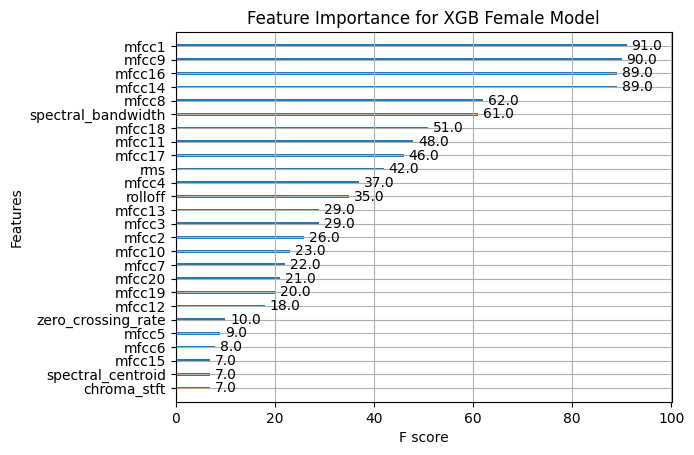

In [20]:
'''Feature Importance for XGB male model
'''
xgb.plot_importance(model)
plt.title('Feature Importance for XGB Female Model')
plt.show()

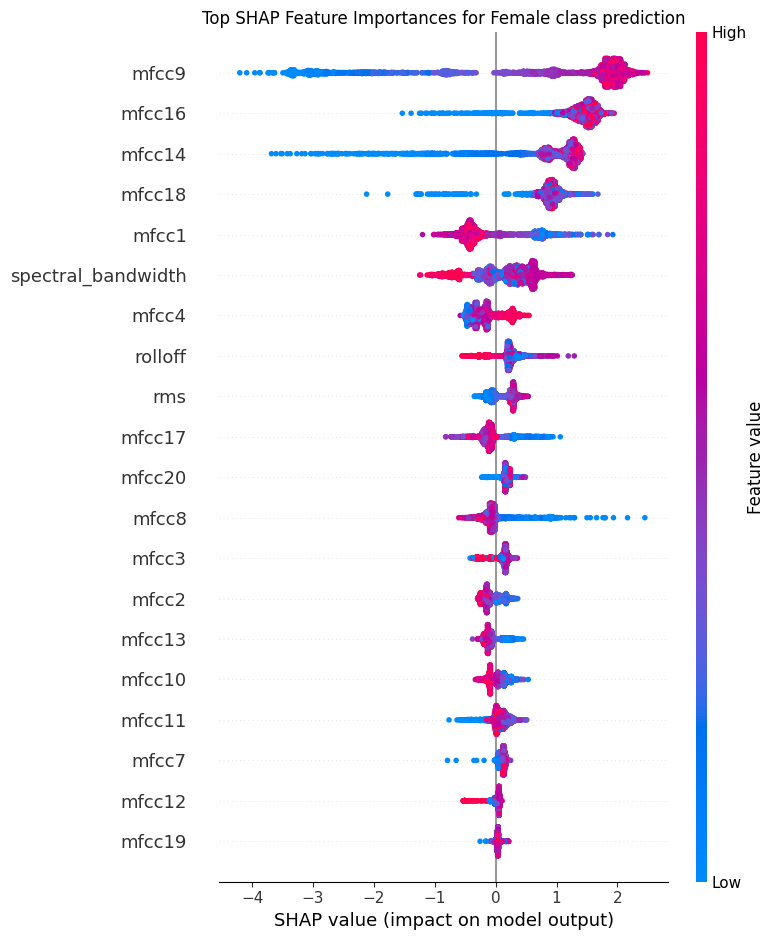

In [21]:
'''SHAP feature importance for XGB Female Model'''
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

plt.figure(figsize=(20, 12))
shap.summary_plot(shap_values, X_test, show=False, rng=42)
plt.title('Top SHAP Feature Importances for Female class prediction')
plt.tight_layout()
plt.show()


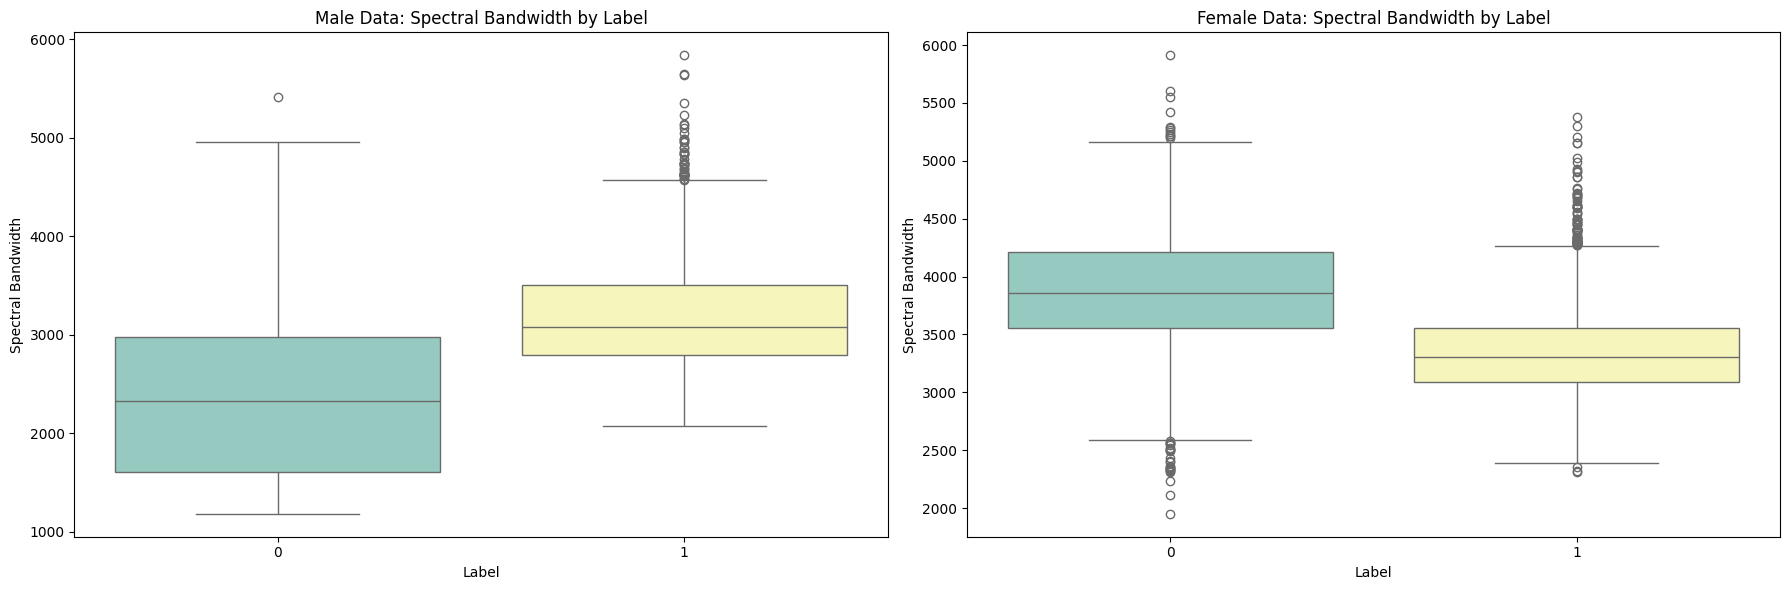

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create side-by-side plots
fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharey=False)

# Male dataset plot
sns.boxplot(
    x='LABEL',
    y='spectral_bandwidth',
    data=male_combined_df,
    hue='LABEL',
    palette='Set3',
    ax=axes[0],
    legend=False
)
axes[0].set_title('Male Data: Spectral Bandwidth by Label')
axes[0].set_xlabel('Label')
axes[0].set_ylabel('Spectral Bandwidth')

# Female dataset plot
sns.boxplot(
    x='LABEL',
    y='spectral_bandwidth',
    data=df,
    hue='LABEL',
    palette='Set3',
    ax=axes[1],
    legend=False
)
axes[1].set_title('Female Data: Spectral Bandwidth by Label')
axes[1].set_xlabel('Label')
axes[1].set_ylabel('Spectral Bandwidth')  # Corrected label

# Display plots
plt.tight_layout()
plt.show()
